# Phân Tích Dữ Liệu Sinh Viên


In [404]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
import re



In [405]:
df_raw = pd.read_excel('../crawl/crawl_data/crawled_data.xlsx')

print(f"Kích thước dữ liệu ban đầu: {df_raw.shape}")
df_raw.head()

Kích thước dữ liệu ban đầu: (400, 13)


,column_1,column_2,column_3,column_4,column_5,column_6,column_7,column_8,column_9,column_10,column_11,column_12,column_13
0,NaN,SV1000,Khoa Hải Bùi,27/09/2003,09 7457 9208,dangjane@example.com,hà nội,NaN,4.5510,5.2921,Err,NaN,NaN
1,NaN,SV1001,Quý cô Hương Đặng,10/12/2003,2 3815 6873,maijane@example.org,Hải Phòng,8.6772,2.5911,NaN,Err,NaN,NaN
2,NaN,SV1002,Nam Trần,2005-08-16,+84-73-982 5638,—,Hải Phòng,6.1120,3.0486,9.2764,6.15,NaN,NaN
3,NaN,SV1003,Tú Lê,11/10/2005,+84 05 8860084,—,HN,-3.2000,0.0487,4.0957,0.31,NaN,NaN
4,NaN,SV1004,Phương Mai Bảo Lê,13/03/2004,(00) 4680 9376,jle@example.com,Cần Thơ,5.3585,3.2529,-2.8100,1.93,NaN,NaN


# Làm sạch dữ liệu 

## I. Làm sạch cấu trúc dữ liệu

In [406]:
# Tạo bản sao để xử lý
df = df_raw.copy()

# Đổi tên cột theo cấu trúc chuẩn
df.columns = ['Empty', 'ID', 'Fullname', 'Birthday', 'Phone', 'Email', 'Hometown', 
              'Math', 'Literature', 'Eng', 'Avg', 'Action1', 'Action2']

# Loại bỏ cột rỗng và 2 cột Action
df = df.drop(columns=['Empty', 'Action1', 'Action2'])

print("Cấu trúc dữ liệu sau khi chuẩn hóa:")
print(f"Kích thước: {df.shape}")
print(f"Các cột: {df.columns.tolist()}")
df.head()

Cấu trúc dữ liệu sau khi chuẩn hóa:
Kích thước: (400, 10)
Các cột: ['ID', 'Fullname', 'Birthday', 'Phone', 'Email', 'Hometown', 'Math', 'Literature', 'Eng', 'Avg']


,ID,Fullname,Birthday,Phone,Email,Hometown,Math,Literature,Eng,Avg
0,SV1000,Khoa Hải Bùi,27/09/2003,09 7457 9208,dangjane@example.com,hà nội,NaN,4.5510,5.2921,Err
1,SV1001,Quý cô Hương Đặng,10/12/2003,2 3815 6873,maijane@example.org,Hải Phòng,8.6772,2.5911,NaN,Err
2,SV1002,Nam Trần,2005-08-16,+84-73-982 5638,—,Hải Phòng,6.1120,3.0486,9.2764,6.15
3,SV1003,Tú Lê,11/10/2005,+84 05 8860084,—,HN,-3.2000,0.0487,4.0957,0.31
4,SV1004,Phương Mai Bảo Lê,13/03/2004,(00) 4680 9376,jle@example.com,Cần Thơ,5.3585,3.2529,-2.8100,1.93


In [407]:
# Kiểm tra và xử lý trùng ID
duplicated_ids = df[df['ID'].duplicated(keep=False)]
if len(duplicated_ids) > 0:
    print(f"Phát hiện {len(duplicated_ids)} ID bị trùng")
    df = df.drop_duplicates(subset=['ID'], keep='first')
else:
    print("Không có ID bị trùng")

# Xóa dòng toàn bộ giá trị là NaN
rows_before = len(df)
df = df.dropna(how='all')
rows_removed = rows_before - len(df)
if rows_removed > 0:
    print(f"Đã xóa {rows_removed} dòng toàn bộ giá trị là NaN")
print(f"Dữ liệu sau khi xử lý cấu trúc: {df.shape}")

Không có ID bị trùng
Dữ liệu sau khi xử lý cấu trúc: (400, 10)


## II Làm sạch dữ liệu cá nhân sinh viên

### Xử lý Fullname

In [408]:
def clean_fullname(name):
    if pd.isna(name):
        return np.nan
    # Loại bỏ các tiền tố như "Bà", "Ông",...
    prefixes = ['Bà ', 'Ông ', 'Anh ', 'Chị ', 'Cô ', 'Bác ', 'Quý ông ', 'Quý cô ']
    for prefix in prefixes:
        if str(name).startswith(prefix):
            name = str(name).replace(prefix, '', 1)
    
    # Loại bỏ khoảng trắng dư thừa
    name = ' '.join(str(name).split())
    
    # Chuẩn hóa viết hoa chữ cái đầu mỗi từ
    name = name.title()
    
    return name

df['Fullname'] = df['Fullname'].apply(clean_fullname)

# Xóa dòng có Fullname rỗng
empty_names = df['Fullname'].isna().sum()
df = df.dropna(subset=['Fullname'])
if empty_names > 0:
    print(f"Đã xóa {empty_names} dòng có Fullname rỗng")

df.head(20)


,ID,Fullname,Birthday,Phone,Email,Hometown,Math,Literature,Eng,Avg
0,SV1000,Khoa Hải Bùi,27/09/2003,09 7457 9208,dangjane@example.com,hà nội,NaN,4.5510,5.2921,Err
1,SV1001,Hương Đặng,10/12/2003,2 3815 6873,maijane@example.org,Hải Phòng,8.6772,2.5911,NaN,Err
2,SV1002,Nam Trần,2005-08-16,+84-73-982 5638,—,Hải Phòng,6.1120,3.0486,9.2764,6.15
3,SV1003,Tú Lê,11/10/2005,+84 05 8860084,—,HN,-3.2000,0.0487,4.0957,0.31
4,SV1004,Phương Mai Bảo Lê,13/03/2004,(00) 4680 9376,jle@example.com,Cần Thơ,5.3585,3.2529,-2.8100,1.93
5,SV1005,Nhật Đặng,2003-06-21,(03) 9701 9346abc,janehoang@example.net,CẦN THƠ,NaN,5.7078,8.1989,Err
6,SV1006,Tú Đặng,30/01/2004,+84-65-838 3172,dangjane@example.com,HCM,6.3400,5.4848,6.9473,6.26
7,SV1007,Lan Dương,2006-04-07,+84 15 2824664,janemai@example.org,hải phòng,8.5081,6.1579,3.6027,6.09
8,SV1008,Hồng Bùi,32/13/2002,+84-8,emai@example.org,NaN,6.0681,9.0736,100.0000,38.38
9,SV1009,Bảo Mai,13/08/2003,03 5956 8782,hoangjohn@example.com,Ho Chi Minh City,NaN,8.8006,NaN,Err


### Xử lý Birthday và tính Age

In [409]:
def parse_birthday(date_str):
    if pd.isna(date_str) or str(date_str).lower() == 'unknown':
        return np.nan
    
    date_str = str(date_str).strip()
    
    # Thử các định dạng khác nhau
    formats = ['%d/%m/%Y', '%Y-%m-%d', '%d-%m-%Y']
    
    for fmt in formats:
        try:
            date_obj = datetime.strptime(date_str, fmt)
            # Kiểm tra ngày hợp lệ (không phải ngày như 32/13/2002)
            if 1990 <= date_obj.year <= 2010 and 1 <= date_obj.month <= 12 and 1 <= date_obj.day <= 31:
                return date_obj.strftime('%Y-%m-%d')
        except:
            continue
    
    return np.nan

# Áp dụng làm sạch
invalid_birthdays_before = df['Birthday'].isna().sum()
df['Birthday'] = df['Birthday'].apply(parse_birthday)
invalid_birthdays_after = df['Birthday'].isna().sum()
cleaned_birthdays = invalid_birthdays_after - invalid_birthdays_before

if cleaned_birthdays > 0:
    print(f"Đã set {cleaned_birthdays} ngày sinh không hợp lệ thành NaN")

# Tính tuổi
def calculate_age(birthday):
    if pd.isna(birthday):
        return np.nan
    try:
        birth_date = datetime.strptime(birthday, '%Y-%m-%d')
        today = datetime(2026, 1, 20)  # Current date
        age = today.year - birth_date.year - ((today.month, today.day) < (birth_date.month, birth_date.day))
        return age
    except:
        return np.nan

df['Age'] = df['Birthday'].apply(calculate_age)

# Loại các giá trị tuổi không hợp lý
invalid_age_count = ((df['Age'] < 17) | (df['Age'] > 30)).sum()
df.loc[(df['Age'] < 17) | (df['Age'] > 30), 'Age'] = np.nan

if invalid_age_count > 0:
    print(f"Đã set {invalid_age_count} tuổi không hợp lý (<17 hoặc >30) thành NaN")

print("Đã làm sạch Birthday và tính Age")
print(f"Số ngày sinh hợp lệ: {df['Birthday'].notna().sum()}")
print(f"Số tuổi hợp lệ: {df['Age'].notna().sum()}")
print(f"Khoảng tuổi: {df['Age'].min():.0f} - {df['Age'].max():.0f}")

Đã set 84 ngày sinh không hợp lệ thành NaN
Đã làm sạch Birthday và tính Age
Số ngày sinh hợp lệ: 316
Số tuổi hợp lệ: 316
Khoảng tuổi: 18 - 24


### Xử lý Phone

In [410]:
def clean_phone(phone):
    if pd.isna(phone):
        return np.nan
    
    # Loại bỏ toàn bộ ký tự không phải số
    phone_digits = re.sub(r'\D', '', str(phone))
    
    # Kiểm tra độ dài hợp lệ (9-11 số)
    if len(phone_digits) < 9 or len(phone_digits) > 11:
        return np.nan
    
    # Chuẩn hóa đầu số về 0
    if phone_digits.startswith('84'):
        phone_digits = '0' + phone_digits[2:]
    
    # Kiểm tra đầu số hợp lệ (phải bắt đầu bằng 0)
    if not phone_digits.startswith('0'):
        return np.nan
    
    return phone_digits

invalid_phones_before = df['Phone'].isna().sum()
df['Phone'] = df['Phone'].apply(clean_phone)
invalid_phones_after = df['Phone'].isna().sum()
cleaned_phones = invalid_phones_after - invalid_phones_before

if cleaned_phones > 0:
    print(f"Đã set {cleaned_phones} số điện thoại không hợp lệ thành NaN")

print(f"Số điện thoại hợp lệ: {df['Phone'].notna().sum()}")
print(f"Ví dụ: {df['Phone'].dropna().head(5).tolist()}")

Đã set 90 số điện thoại không hợp lệ thành NaN
Số điện thoại hợp lệ: 310
Ví dụ: ['0974579208', '0739825638', '0058860084', '0046809376', '0397019346']


### Xử lý Email

In [411]:
def clean_email(email):
    if pd.isna(email) or str(email) == '—' or str(email).strip() == '':
        return np.nan
    
    email = str(email).strip()
    
    # Kiểm tra phải chứa ký tự @
    if '@' not in email:
        return np.nan
    
    # Kiểm tra format cơ bản
    email_pattern = r'^[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}$'
    if not re.match(email_pattern, email):
        return np.nan
    
    return email.lower()

invalid_emails_before = df['Email'].isna().sum()
df['Email'] = df['Email'].apply(clean_email)
invalid_emails_after = df['Email'].isna().sum()
cleaned_emails = invalid_emails_after - invalid_emails_before

if cleaned_emails > 0:
    print(f"Đã set {cleaned_emails} email không hợp lệ thành NaN")

print(f"Email hợp lệ: {df['Email'].notna().sum()}")
print(f"CHECK {df['Email'].dropna().head(5).tolist()}")

Đã set 65 email không hợp lệ thành NaN
Email hợp lệ: 335
CHECK ['dangjane@example.com', 'maijane@example.org', 'jle@example.com', 'janehoang@example.net', 'dangjane@example.com']


### Xử lý Hometown

In [412]:
def clean_hometown(hometown):
    if pd.isna(hometown) or str(hometown).strip() == '':
        return 'Khác'

    h = str(hometown).strip().lower()

    # ===== Hà Nội =====
    if h in ['hn', 'hà nội', 'ha noi', 'hanoi', 'ha nioj', 'hà nội ']:
        return 'Hà Nội'

    # ===== TP.HCM =====
    elif h in [
        'hcm', 'tp hcm', 'tp.hcm', 'tp ho chi minh', 
        'ho chi minh city', 'ho chi minh', 
        'hồ chí minh', 'tp hồ chí minh'
    ]:
        return 'TP.HCM'

    # ===== Hải Phòng =====
    elif h in ['hải phòng', 'hai phong']:
        return 'Hải Phòng'

    # ===== Cần Thơ =====
    elif h in ['cần thơ', 'can tho','tp can tho']:
        return 'Cần Thơ'

    # ===== Đà Nẵng =====
    elif h in ['đà nẵng', 'da nang']:
        return 'Đà Nẵng'

    # ===== Khác =====
    else:
        return 'Khác'

df['Hometown'] = df['Hometown'].apply(clean_hometown)

print("Đã làm sạch Hometown")
print("\nPhân bố quê quán:")
print(df['Hometown'].value_counts())

Đã làm sạch Hometown

Phân bố quê quán:
Hometown
TP.HCM       112
Hà Nội        95
Khác          57
Cần Thơ       48
Hải Phòng     44
Đà Nẵng       44
Name: count, dtype: int64


## 3. Làm sạch dữ liệu điểm số

In [413]:
def clean_score(score):
    if pd.isna(score) or str(score).lower() == 'err' or str(score).strip() == '':
        return np.nan
    
    try:
        score_value = float(score)
        # Kiểm tra điểm hợp lệ (0-10)
        if 0 <= score_value <= 10:
            return round(score_value, 2)
        else:
            return np.nan
    except:
        return np.nan

# Áp dụng cho các môn
score_columns = ['Math', 'Literature', 'Eng']

for col in score_columns:
    invalid_before = df[col].isna().sum()
    df[col] = df[col].apply(clean_score)
    invalid_after = df[col].isna().sum()
    cleaned = invalid_after - invalid_before
    if cleaned > 0:
        print(f"Đã set {cleaned} điểm {col} không hợp lệ thành NaN")

print("Đã làm sạch điểm số")
print("\nSố missing values:")
for col in score_columns:
    missing_count = df[col].isna().sum()
    missing_pct = (missing_count / len(df)) * 100
    print(f"  {col}: {missing_count} ({missing_pct:.2f}%)")

df_before_impute = df.copy()

Đã set 57 điểm Math không hợp lệ thành NaN
Đã set 53 điểm Literature không hợp lệ thành NaN
Đã set 47 điểm Eng không hợp lệ thành NaN
Đã làm sạch điểm số

Số missing values:
  Math: 90 (22.50%)
  Literature: 100 (25.00%)
  Eng: 100 (25.00%)


### Xử lý Missing Values và Outliers

In [414]:
for col in score_columns:
    missing_count = df[col].isna().sum()
    missing_pct = (missing_count / len(df)) * 100

    print(f"\n--- Xử lý cột: {col} ---")
    print(f"Missing: {missing_count}/{len(df)} ({missing_pct:.2f}%)")

    if missing_pct <= 10:
        mean_value = round(df[col].mean(), 2)
        df[col] = df[col].fillna(mean_value)

        print(f"Đã điền {missing_count} missing {col} bằng mean ({mean_value:.2f})")

    else:
        print(f"Giữ nguyên {missing_count} giá trị missing ở cột {col}")



--- Xử lý cột: Math ---
Missing: 90/400 (22.50%)
Giữ nguyên 90 giá trị missing ở cột Math

--- Xử lý cột: Literature ---
Missing: 100/400 (25.00%)
Giữ nguyên 100 giá trị missing ở cột Literature

--- Xử lý cột: Eng ---
Missing: 100/400 (25.00%)
Giữ nguyên 100 giá trị missing ở cột Eng


### Tính lại điểm trung bình (Avg)

In [415]:
df['Avg'] = df[['Math', 'Literature', 'Eng']].mean(axis=1).round(2)

print("Đã tính lại điểm trung bình")
print(df['Avg'].describe())

Đã tính lại điểm trung bình
count    397.000000
mean       4.984030
std        2.147624
min        0.150000
25%        3.520000
50%        5.150000
75%        6.470000
max        9.890000
Name: Avg, dtype: float64


# MỐC II - Kiểm tra và xác nhận dữ liệu sạch

In [416]:
# Kiểm tra dữ liệu sạch
print("=" * 70)
print("KIỂM TRA DỮ LIỆU SAU LÀM SẠCH")
print("=" * 70)

# 1. Kiểm tra điểm nằm trong khoảng 0-10
invalid_scores = 0
for col in score_columns:
    invalid = ((df[col] < 0) | (df[col] > 10)).sum()
    invalid_scores += invalid
    print(f"\n{col}: Không có điểm <0 hoặc >10" if invalid == 0 else f"{col}: Còn {invalid} điểm không hợp lệ")

# 2. Kiểm tra ngày sinh
invalid_birthdays = df['Birthday'].isna().sum()
print(f"\nNgày sinh: {len(df) - invalid_birthdays} hợp lệ, {invalid_birthdays} NaN")

# 3. Thống kê tổng quan
print(f"\n" + "=" * 70)
print("THỐNG KÊ DỮ LIỆU SẠCH")
print("=" * 70)

for col in score_columns + ['Avg']:
    print(f"\n{col}:")
    print(f"  Min: {df[col].min():.2f}")
    print(f"  Max: {df[col].max():.2f}")
    print(f"  Mean: {df[col].mean():.2f}")
    print(f"  Median: {df[col].median():.2f}")
    print(f"  Std: {df[col].std():.2f}")

print(f"\n" + "=" * 70)
print(f"Tổng số sinh viên hợp lệ: {len(df)}")
print("=" * 70)

KIỂM TRA DỮ LIỆU SAU LÀM SẠCH

Math: Không có điểm <0 hoặc >10

Literature: Không có điểm <0 hoặc >10

Eng: Không có điểm <0 hoặc >10

Ngày sinh: 316 hợp lệ, 84 NaN

THỐNG KÊ DỮ LIỆU SẠCH

Math:
  Min: 0.01
  Max: 9.95
  Mean: 4.90
  Median: 4.69
  Std: 2.79

Literature:
  Min: 0.04
  Max: 9.94
  Mean: 5.15
  Median: 5.38
  Std: 2.91

Eng:
  Min: 0.01
  Max: 10.00
  Mean: 5.00
  Median: 4.89
  Std: 3.07

Avg:
  Min: 0.15
  Max: 9.89
  Mean: 4.98
  Median: 5.15
  Std: 2.15

Tổng số sinh viên hợp lệ: 400


### So sánh trước và sau làm sạch

In [417]:
# Bảng so sánh
comparison_df = pd.DataFrame({
    'Metric': ['Số dòng', 'Số cột', 'Math missing', 'Literature missing', 'Eng missing'],
    'Trước làm sạch': [
        len(df_raw),
        len(df_raw.columns),
        f"{df_raw['column_8'].isna().sum()} ({(df_raw['column_8'].isna().sum()/len(df_raw)*100):.1f}%)",
        f"{df_raw['column_9'].isna().sum()} ({(df_raw['column_9'].isna().sum()/len(df_raw)*100):.1f}%)",
        f"{df_raw['column_10'].isna().sum()} ({(df_raw['column_10'].isna().sum()/len(df_raw)*100):.1f}%)"
    ],
    'Sau làm sạch': [
        len(df),
        len(df.columns),
        f"{df['Math'].isna().sum()} ({(df['Math'].isna().sum()/len(df)*100):.1f}%)",
        f"{df['Literature'].isna().sum()} ({(df['Literature'].isna().sum()/len(df)*100):.1f}%)",
        f"{df['Eng'].isna().sum()} ({(df['Eng'].isna().sum()/len(df)*100):.1f}%)"
    ]
})

print("\nSO SÁNH TRƯỚC VÀ SAU LÀM SẠCH:")
print(comparison_df.to_string(index=False))


SO SÁNH TRƯỚC VÀ SAU LÀM SẠCH:
            Metric Trước làm sạch Sau làm sạch
           Số dòng            400          400
            Số cột             13           11
      Math missing      33 (8.2%)   90 (22.5%)
Literature missing     47 (11.8%)  100 (25.0%)
       Eng missing     53 (13.2%)  100 (25.0%)


### Xuất dữ liệu sạch ra file XLSX

In [418]:
# Xuất ra file XLSX
output_path = 'students_clean.xlsx'
df.to_excel(output_path, index=False, engine='openpyxl')

print(f"\nĐã xuất dữ liệu sạch ra file: {output_path}")
print(f"Kích thước: {df.shape}")
print(f"Các cột: {df.columns.tolist()}")


Đã xuất dữ liệu sạch ra file: students_clean.xlsx
Kích thước: (400, 11)
Các cột: ['ID', 'Fullname', 'Birthday', 'Phone', 'Email', 'Hometown', 'Math', 'Literature', 'Eng', 'Avg', 'Age']


# III - Phân tích mô tả dữ liệu

In [419]:
# Tổng quan dữ liệu
print("=" * 70)
print("PHÂN TÍCH MÔ TẢ DỮ LIỆU")
print("=" * 70)

print(f"\nTổng số sinh viên hợp lệ: {len(df)}")
print("\nTỷ lệ thiếu dữ liệu theo cột:")

for col in df.columns:
    missing_count = df[col].isna().sum()
    missing_pct = (missing_count / len(df)) * 100
    print(f"  {col:15} : {missing_count:3} ({missing_pct:5.2f}%)")

print("\nĐiểm trung bình các môn:")
print(f"  Toán (Math):        {df['Math'].mean():.2f}")
print(f"  Văn (Literature):   {df['Literature'].mean():.2f}")
print(f"  Anh (Eng):          {df['Eng'].mean():.2f}")

PHÂN TÍCH MÔ TẢ DỮ LIỆU

Tổng số sinh viên hợp lệ: 400

Tỷ lệ thiếu dữ liệu theo cột:
  ID              :   0 ( 0.00%)
  Fullname        :   0 ( 0.00%)
  Birthday        :  84 (21.00%)
  Phone           :  90 (22.50%)
  Email           :  65 (16.25%)
  Hometown        :   0 ( 0.00%)
  Math            :  90 (22.50%)
  Literature      : 100 (25.00%)
  Eng             : 100 (25.00%)
  Avg             :   3 ( 0.75%)
  Age             :  84 (21.00%)

Điểm trung bình các môn:
  Toán (Math):        4.90
  Văn (Literature):   5.15
  Anh (Eng):          5.00


### Phân loại học lực

In [ ]:
# Phân loại học lực theo Avg
def classify_performance(avg):
    # if row[['Math','Literature','Eng']].isna().any():
    #     return 'Không đủ dữ liệu'
    # avg = row['Avg']
    if pd.isna(avg):
        return 'Không xác định'
    elif avg < 5:
        return 'Yếu'
    elif avg < 6.5:
        return 'Trung bình'
    elif avg < 8:
        return 'Khá'
    elif avg < 9:
        return 'Giỏi'
    else:
        return 'Xuất sắc'

df['Performance'] = df['Avg'].apply(classify_performance)

print("\nPhân loại học lực:")
performance_counts = df['Performance'].value_counts()
performance_pct = (performance_counts / len(df) * 100).round(2)

for category in ['Yếu', 'Trung bình', 'Khá', 'Giỏi']:
    if category in performance_counts.index:
        print(f"  {category:15} : {performance_counts[category]:3} sinh viên ({performance_pct[category]:5.2f}%)")


Phân loại học lực:
  Yếu             : 187 sinh viên (46.75%)
  Trung bình      : 112 sinh viên (28.00%)
  Khá             :  60 sinh viên (15.00%)
  Giỏi            :  28 sinh viên ( 7.00%)


### Trực quan hóa phân bố điểm

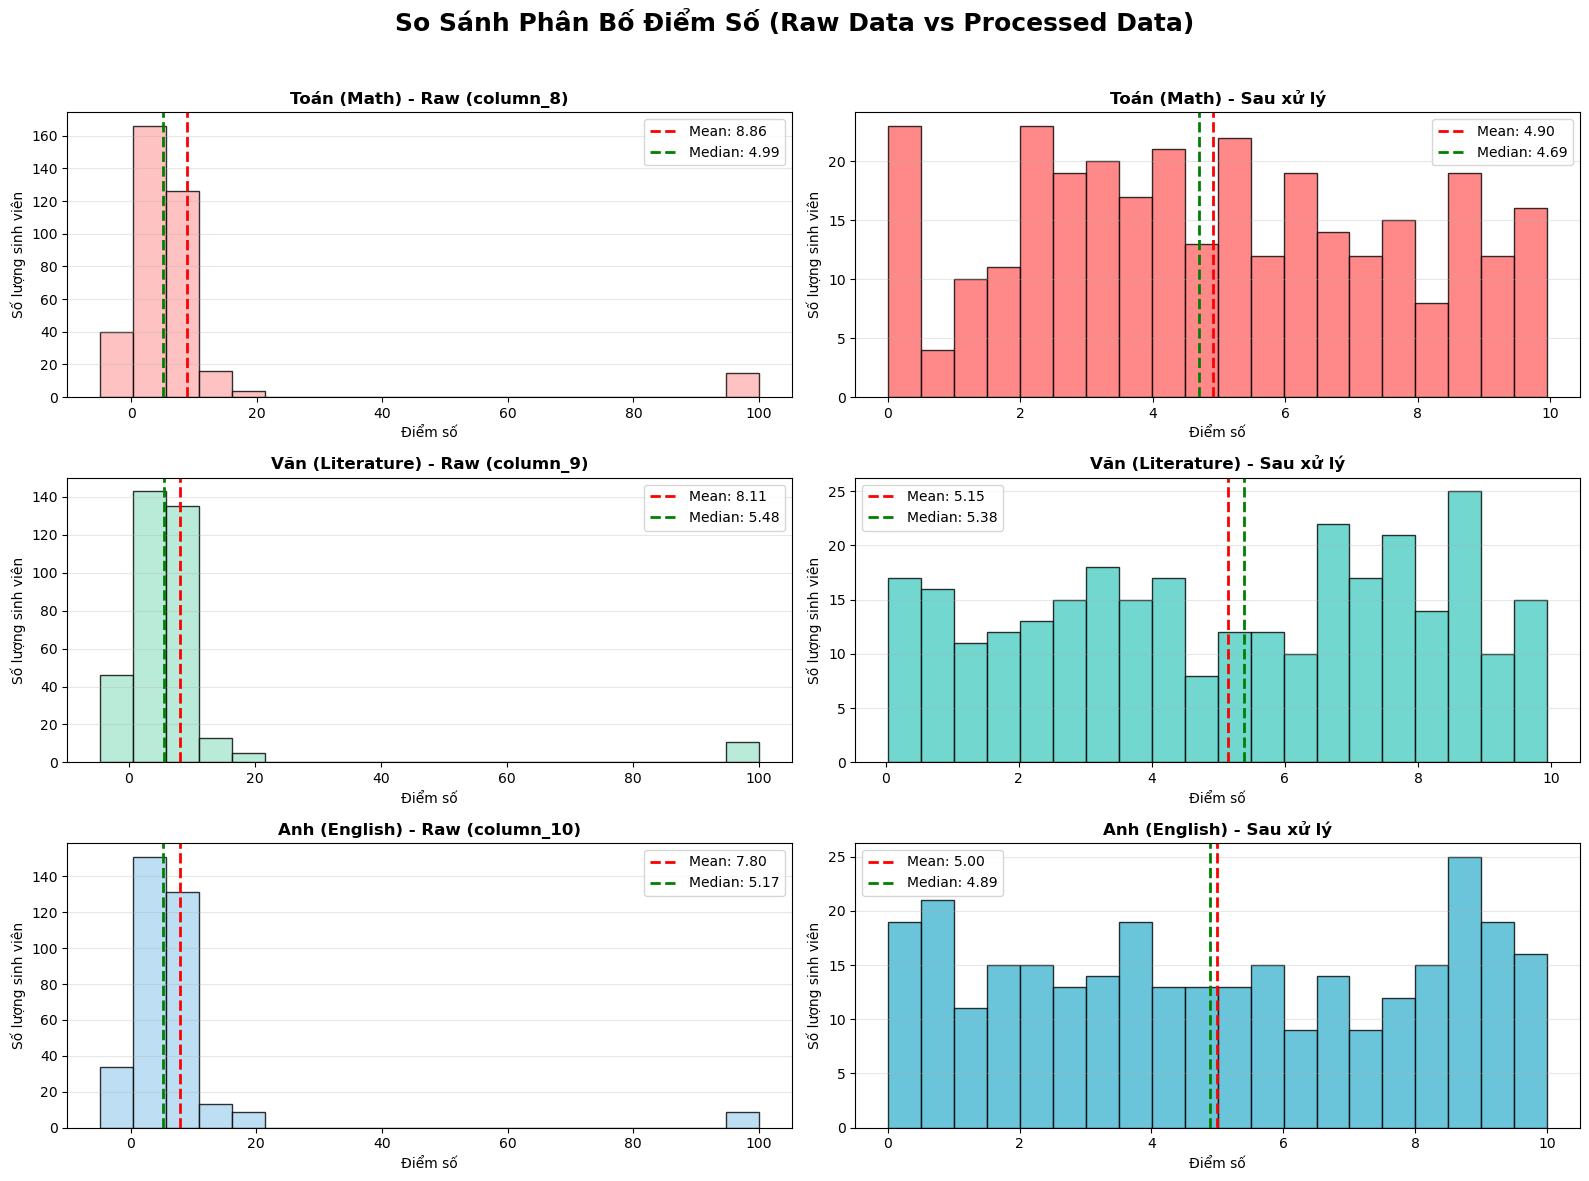

In [421]:
# So sánh phân bố điểm số
raw_to_processed = {
    'column_8': 'Math',
    'column_9': 'Literature',
    'column_10': 'Eng'
}

titles = {
    'Math': 'Toán (Math)',
    'Literature': 'Văn (Literature)',
    'Eng': 'Anh (English)'
}

colors_raw = ['#FFB3B3', '#A8E6CF', '#AED6F1']
colors_processed = ['#FF6B6B', '#4ECDC4', '#45B7D1']

fig, axes = plt.subplots(len(raw_to_processed), 2, figsize=(16, 12))
fig.suptitle('So Sánh Phân Bố Điểm Số (Raw Data vs Processed Data)', 
             fontsize=18, fontweight='bold')

for i, (raw_col, proc_col) in enumerate(raw_to_processed.items()):
    
    # ===== RAW DATA =====
    raw_data = df_raw[raw_col].dropna()
    ax_raw = axes[i, 0]

    ax_raw.hist(raw_data, bins=20, color=colors_raw[i], alpha=0.8, edgecolor='black')
    ax_raw.axvline(raw_data.mean(), color='red', linestyle='--', linewidth=2,
                   label=f'Mean: {raw_data.mean():.2f}')
    ax_raw.axvline(raw_data.median(), color='green', linestyle='--', linewidth=2,
                   label=f'Median: {raw_data.median():.2f}')

    ax_raw.set_title(f"{titles[proc_col]} - Raw ({raw_col})", fontsize=12, fontweight='bold')
    ax_raw.set_xlabel('Điểm số')
    ax_raw.set_ylabel('Số lượng sinh viên')
    ax_raw.legend()
    ax_raw.grid(axis='y', alpha=0.3)

    # ===== PROCESSED DATA =====
    proc_data = df[proc_col].dropna()
    ax_proc = axes[i, 1]

    ax_proc.hist(proc_data, bins=20, color=colors_processed[i], alpha=0.8, edgecolor='black')
    ax_proc.axvline(proc_data.mean(), color='red', linestyle='--', linewidth=2,
                    label=f'Mean: {proc_data.mean():.2f}')
    ax_proc.axvline(proc_data.median(), color='green', linestyle='--', linewidth=2,
                    label=f'Median: {proc_data.median():.2f}')

    ax_proc.set_title(f"{titles[proc_col]} - Sau xử lý", fontsize=12, fontweight='bold')
    ax_proc.set_xlabel('Điểm số')
    ax_proc.set_ylabel('Số lượng sinh viên')
    ax_proc.legend()
    ax_proc.grid(axis='y', alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [422]:
# subjects = ['Math', 'Literature', 'Eng']
# titles = ['Toán (Math)', 'Văn (Literature)', 'Anh (English)']

# colors_before = ['#FADBD8', '#D5F5E3', '#D6EAF8']   
# colors_after  = ['#E74C3C', '#1ABC9C', '#3498DB'] 

# fig, axes = plt.subplots(len(subjects), 2, figsize=(16, 12))
# fig.suptitle('So Sánh Boxplot Trước và Sau Khi Điền Mean', 
#              fontsize=18, fontweight='bold')

# for i, subject in enumerate(subjects):

#     # ===== BEFORE (chưa fill mean) =====
#     before_data = df_before_impute[subject].dropna()  
#     ax_before = axes[i, 0]

#     bp_before = ax_before.boxplot(before_data, patch_artist=True, widths=0.5)
#     bp_before['boxes'][0].set_facecolor(colors_before[i])
#     bp_before['boxes'][0].set_alpha(0.7)

#     ax_before.set_title(f"{titles[i]} - Trước điền mean", fontsize=12, fontweight='bold')
#     ax_before.set_ylabel('Điểm số')
#     ax_before.set_xticklabels([''])
#     ax_before.grid(axis='y', alpha=0.3)

#     stats_before = (
#         f"Min: {before_data.min():.2f}\n"
#         f"Max: {before_data.max():.2f}\n"
#         f"Mean: {before_data.mean():.2f}\n"
#         f"Median: {before_data.median():.2f}"
#     )
#     ax_before.text(1.15, before_data.median(), stats_before,
#                    transform=ax_before.transData,
#                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
#                    fontsize=9)

#     # ===== AFTER (sau fill mean) =====
#     after_data = df[subject].dropna()  
#     ax_after = axes[i, 1]

#     bp_after = ax_after.boxplot(after_data, patch_artist=True, widths=0.5)
#     bp_after['boxes'][0].set_facecolor(colors_after[i])
#     bp_after['boxes'][0].set_alpha(0.7)

#     ax_after.set_title(f"{titles[i]} - Sau điền mean", fontsize=12, fontweight='bold')
#     ax_after.set_ylabel('Điểm số')
#     ax_after.set_xticklabels([''])
#     ax_after.grid(axis='y', alpha=0.3)

#     stats_after = (
#         f"Min: {after_data.min():.2f}\n"
#         f"Max: {after_data.max():.2f}\n"
#         f"Mean: {after_data.mean():.2f}\n"
#         f"Median: {after_data.median():.2f}"
#     )
#     ax_after.text(1.15, after_data.median(), stats_after,
#                   transform=ax_after.transData,
#                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
#                   fontsize=9)

# plt.tight_layout(rect=[0, 0, 1, 0.96])
# plt.show()


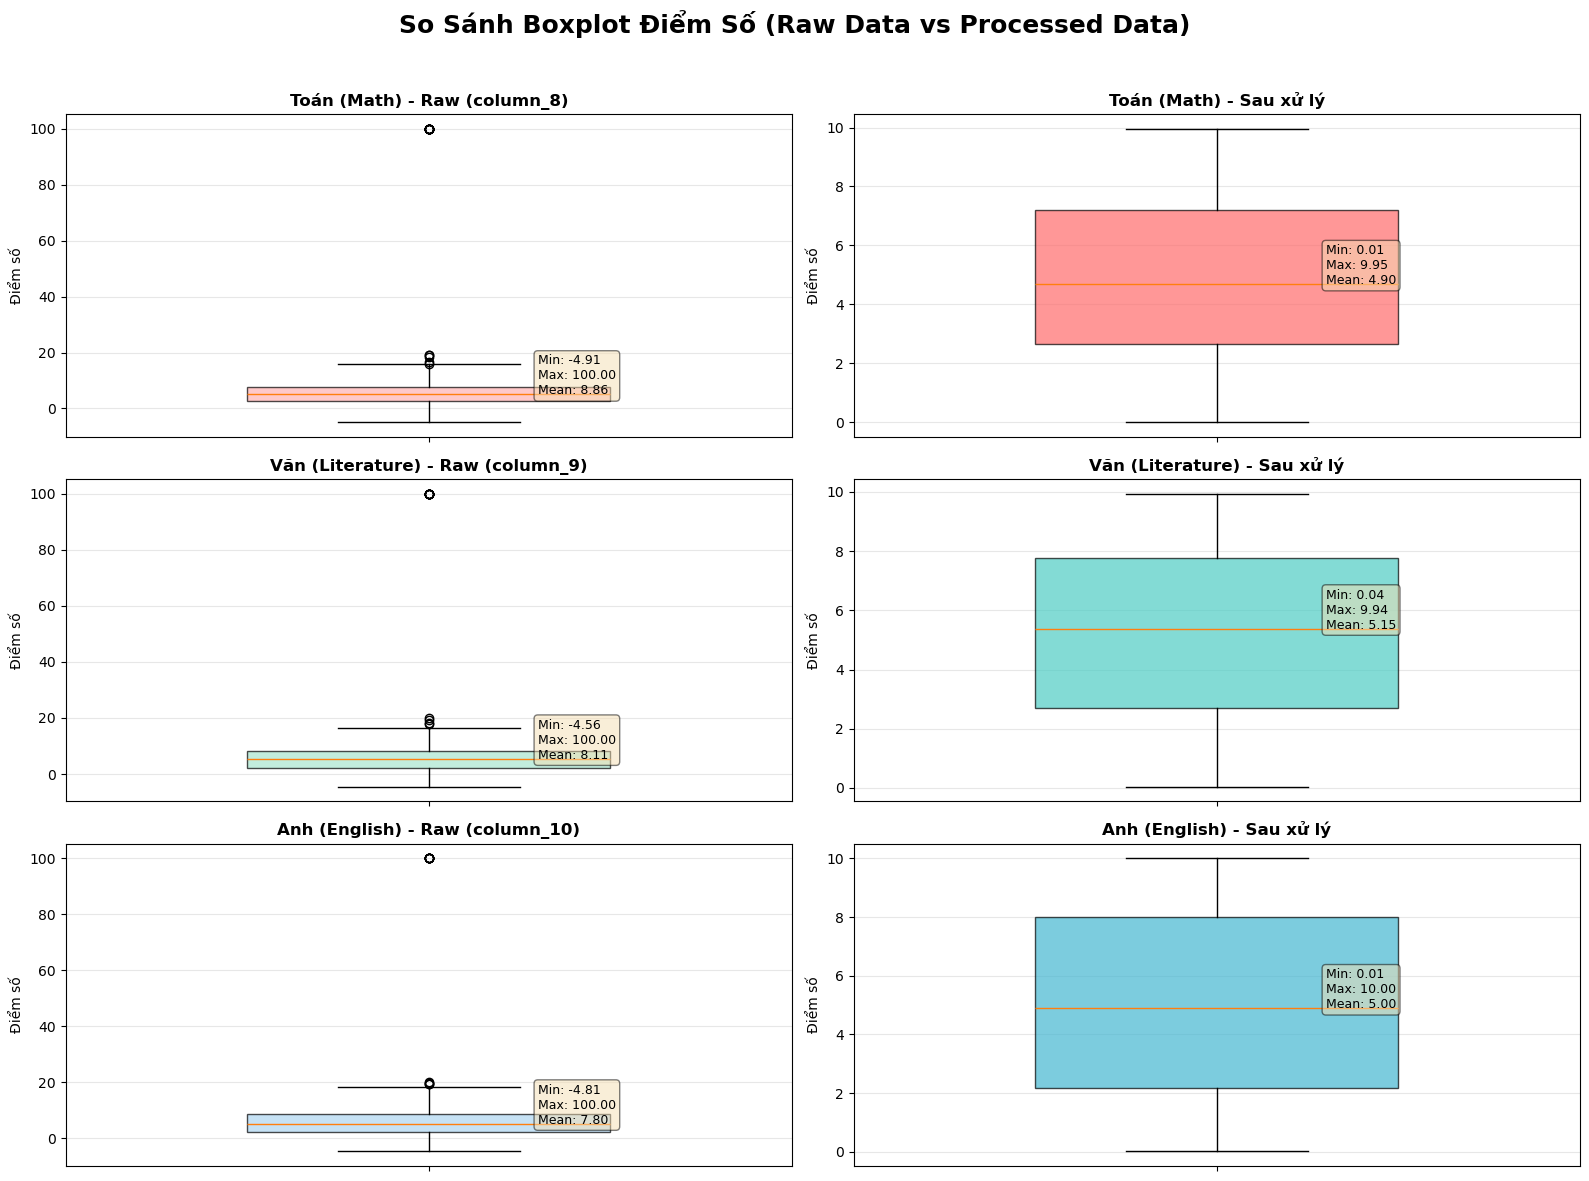

In [423]:
raw_to_processed = {
    'column_8': 'Math',
    'column_9': 'Literature',
    'column_10': 'Eng'
}

titles = {
    'Math': 'Toán (Math)',
    'Literature': 'Văn (Literature)',
    'Eng': 'Anh (English)'
}

colors_raw = ['#FFB3B3', '#A8E6CF', '#AED6F1']
colors_processed = ['#FF6B6B', '#4ECDC4', '#45B7D1']

fig, axes = plt.subplots(len(raw_to_processed), 2, figsize=(16, 12))
fig.suptitle('So Sánh Boxplot Điểm Số (Raw Data vs Processed Data)', 
             fontsize=18, fontweight='bold')

for i, (raw_col, proc_col) in enumerate(raw_to_processed.items()):
    
    # ===== RAW DATA =====
    raw_data = df_raw[raw_col].dropna()
    ax_raw = axes[i, 0]

    bp_raw = ax_raw.boxplot(raw_data, patch_artist=True, widths=0.5)
    bp_raw['boxes'][0].set_facecolor(colors_raw[i])
    bp_raw['boxes'][0].set_alpha(0.7)

    ax_raw.set_title(f"{titles[proc_col]} - Raw ({raw_col})", fontsize=12, fontweight='bold')
    ax_raw.set_ylabel('Điểm số')
    ax_raw.set_xticklabels([''])
    ax_raw.grid(axis='y', alpha=0.3)

    stats_raw = f"Min: {raw_data.min():.2f}\nMax: {raw_data.max():.2f}\nMean: {raw_data.mean():.2f}"
    ax_raw.text(1.15, raw_data.median(), stats_raw,
                transform=ax_raw.transData,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                fontsize=9)

    # ===== PROCESSED DATA =====
    proc_data = df[proc_col].dropna()
    ax_proc = axes[i, 1]

    bp_proc = ax_proc.boxplot(proc_data, patch_artist=True, widths=0.5)
    bp_proc['boxes'][0].set_facecolor(colors_processed[i])
    bp_proc['boxes'][0].set_alpha(0.7)

    ax_proc.set_title(f"{titles[proc_col]} - Sau xử lý", fontsize=12, fontweight='bold')
    ax_proc.set_ylabel('Điểm số')
    ax_proc.set_xticklabels([''])
    ax_proc.grid(axis='y', alpha=0.3)

    stats_proc = f"Min: {proc_data.min():.2f}\nMax: {proc_data.max():.2f}\nMean: {proc_data.mean():.2f}"
    ax_proc.text(1.15, proc_data.median(), stats_proc,
                 transform=ax_proc.transData,
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                 fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


# IV - Phân tích so sánh và tương quan điểm số

In [424]:
# Tính ma trận tương quan
correlation_matrix = df[['Math', 'Literature', 'Eng']].corr()

print("=" * 70)
print("PHÂN TÍCH TƯƠNG QUAN ĐIỂM SỐ")
print("=" * 70)

print("\nMa trận tương quan:")
print(correlation_matrix.round(3))

# Phân tích chi tiết
print("\nPhân tích tương quan:")
corr_math_eng = correlation_matrix.loc['Math', 'Eng']
corr_lit_eng = correlation_matrix.loc['Literature', 'Eng']
corr_math_lit = correlation_matrix.loc['Math', 'Literature']

def interpret_correlation(corr):
    if abs(corr) < 0.3:
        return "Yếu"
    elif abs(corr) < 0.7:
        return "Trung bình"
    else:
        return "Mạnh"

print(f"  Math - Eng:        {corr_math_eng:.3f} ({interpret_correlation(corr_math_eng)})")
print(f"  Literature - Eng:  {corr_lit_eng:.3f} ({interpret_correlation(corr_lit_eng)})")
print(f"  Math - Literature: {corr_math_lit:.3f} ({interpret_correlation(corr_math_lit)})")

PHÂN TÍCH TƯƠNG QUAN ĐIỂM SỐ

Ma trận tương quan:
             Math  Literature    Eng
Math        1.000       0.029  0.025
Literature  0.029       1.000  0.042
Eng         0.025       0.042  1.000

Phân tích tương quan:
  Math - Eng:        0.025 (Yếu)
  Literature - Eng:  0.042 (Yếu)
  Math - Literature: 0.029 (Yếu)


### Scatter Plot - Tương quan giữa các môn

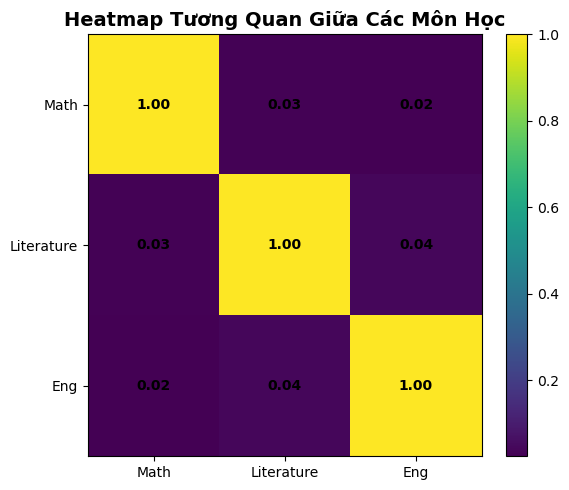

In [425]:
corr = df[['Math', 'Literature', 'Eng']].corr()

plt.figure(figsize=(6, 5))
im = plt.imshow(corr, aspect='auto')
plt.colorbar(im)

subjects = corr.columns.tolist()
plt.xticks(range(len(subjects)), subjects)
plt.yticks(range(len(subjects)), subjects)

# Ghi hệ số correlation lên từng ô
for i in range(len(subjects)):
    for j in range(len(subjects)):
        value = corr.iloc[i, j]
        plt.text(j, i, f"{value:.2f}", ha="center", va="center", fontweight="bold")

plt.title('Heatmap Tương Quan Giữa Các Môn Học', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Diễn giải kết quả

In [426]:
print("\n" + "=" * 70)
print("DIỄN GIẢI KẾT QUẢ TƯƠNG QUAN")
print("=" * 70)

print(f"\n1. Tương quan Math - Eng ({corr_math_eng:.3f}):")
if corr_math_eng > 0.3:
    print("   Có tương quan dương, sinh viên giỏi Toán thường cũng giỏi Anh.")
    print("   Cả hai môn đều yêu cầu tư duy logic và khả năng phân tích.")
else:
    print("   Tương quan yếu, kết quả Toán và Anh không phụ thuộc nhiều vào nhau.")

print(f"\n2. Tương quan Literature - Eng ({corr_lit_eng:.3f}):")
if corr_lit_eng > 0.3:
    print("   Có tương quan dương, sinh viên giỏi Văn thường cũng giỏi Anh.")
    print("   Cả hai môn đều là ngôn ngữ, yêu cầu kỹ năng đọc hiểu và diễn đạt.")
else:
    print("   Tương quan yếu, kỹ năng tiếng mẹ đẻ không đảm bảo kỹ năng ngoại ngữ.")

print(f"\n3. Tương quan Math - Literature ({corr_math_lit:.3f}):")
if corr_math_lit > 0.3:
    print("   Có tương quan dương, sinh viên học tốt thường giỏi cả hai môn.")
    print("   Phản ánh năng lực học tập tổng thể của sinh viên.")
else:
    print("   Tương quan yếu, Toán và Văn là hai lĩnh vực khác biệt.")
    print("   Sinh viên có thể giỏi môn này nhưng yếu môn kia.")


DIỄN GIẢI KẾT QUẢ TƯƠNG QUAN

1. Tương quan Math - Eng (0.025):
   Tương quan yếu, kết quả Toán và Anh không phụ thuộc nhiều vào nhau.

2. Tương quan Literature - Eng (0.042):
   Tương quan yếu, kỹ năng tiếng mẹ đẻ không đảm bảo kỹ năng ngoại ngữ.

3. Tương quan Math - Literature (0.029):
   Tương quan yếu, Toán và Văn là hai lĩnh vực khác biệt.
   Sinh viên có thể giỏi môn này nhưng yếu môn kia.


# V - Phân tích theo quê quán

In [427]:
# Thống kê theo quê quán
print("=" * 70)
print("PHÂN TÍCH THEO QUÊ QUÁN")
print("=" * 70)

print("\nSố lượng sinh viên theo quê quán:")
hometown_counts = df['Hometown'].value_counts()
for hometown, count in hometown_counts.items():
    pct = (count / len(df)) * 100
    print(f"  {hometown:15} : {count:3} sinh viên ({pct:5.2f}%)")

# So sánh điểm trung bình theo quê quán
print("\nĐiểm trung bình các môn theo quê quán:")
hometown_avg = df.groupby('Hometown')[['Math', 'Literature', 'Eng', 'Avg']].mean()
print(hometown_avg.round(2))

PHÂN TÍCH THEO QUÊ QUÁN

Số lượng sinh viên theo quê quán:
  TP.HCM          : 112 sinh viên (28.00%)
  Hà Nội          :  95 sinh viên (23.75%)
  Khác            :  57 sinh viên (14.25%)
  Cần Thơ         :  48 sinh viên (12.00%)
  Hải Phòng       :  44 sinh viên (11.00%)
  Đà Nẵng         :  44 sinh viên (11.00%)

Điểm trung bình các môn theo quê quán:
           Math  Literature   Eng   Avg
Hometown                               
Cần Thơ    5.65        5.27  5.21  5.30
Hà Nội     4.43        5.07  4.96  4.85
Hải Phòng  5.23        4.55  4.35  4.74
Khác       4.67        5.21  4.87  4.80
TP.HCM     4.72        5.34  4.99  4.97
Đà Nẵng    5.44        5.20  5.72  5.42


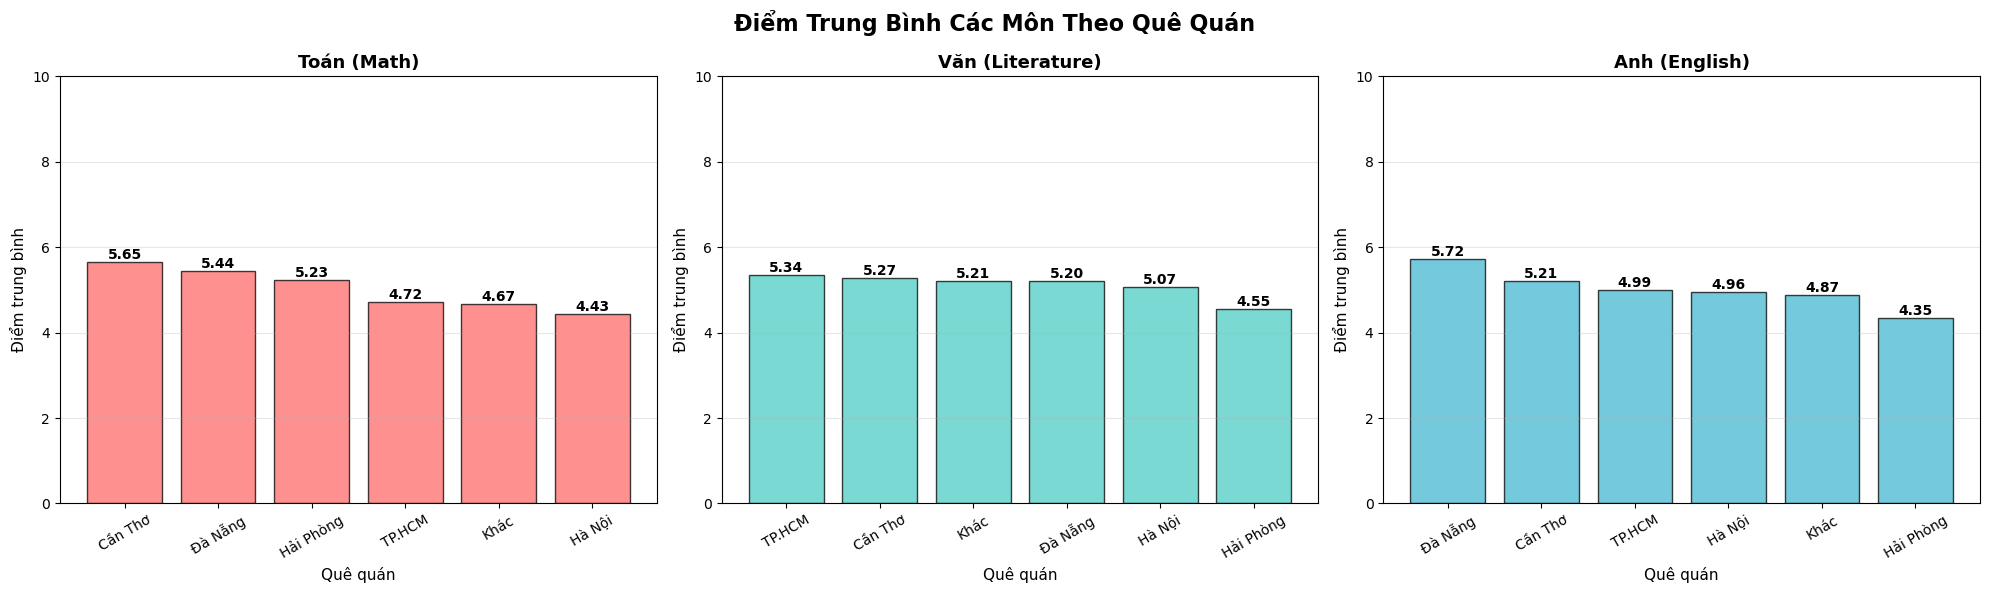

In [428]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Điểm Trung Bình Các Môn Theo Quê Quán', fontsize=16, fontweight='bold')

subjects = ['Math', 'Literature', 'Eng']
titles = ['Toán (Math)', 'Văn (Literature)', 'Anh (English)']
colors_list = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for i, (subject, title, color) in enumerate(zip(subjects, titles, colors_list)):
    ax = axes[i]
    hometown_subject_avg = df.groupby('Hometown')[subject].mean().sort_values(ascending=False)
    bars = ax.bar(hometown_subject_avg.index, hometown_subject_avg.values,
                  color=color, alpha=0.75, edgecolor='black')
    
    # Thêm giá trị trên mỗi cột
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax.set_xlabel('Quê quán', fontsize=11)
    ax.set_ylabel('Điểm trung bình', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, 10)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


boxplot theo quê quán

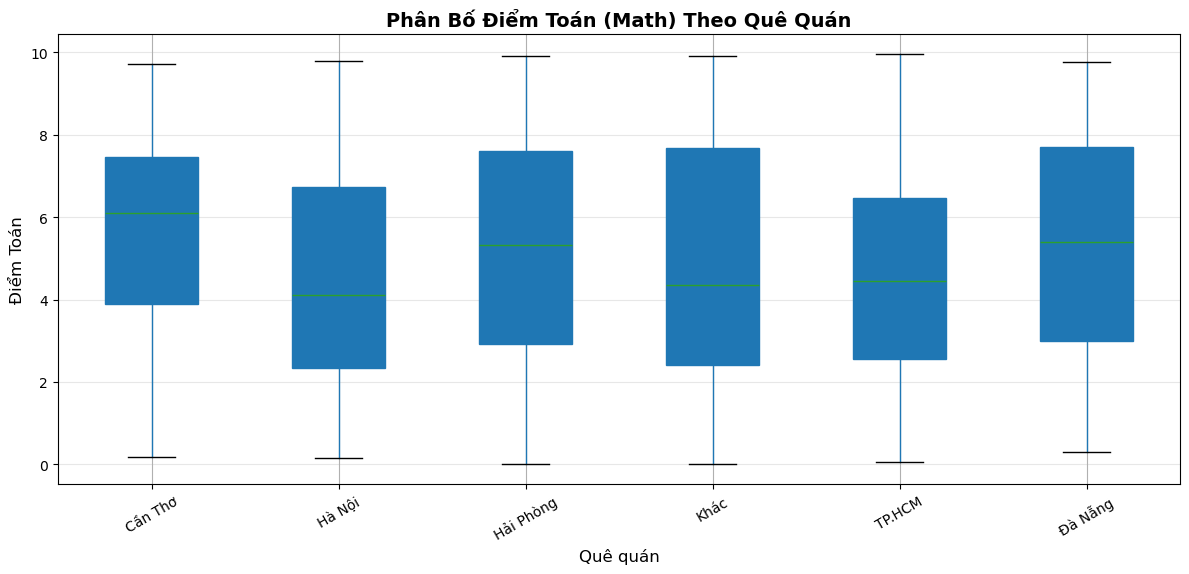

In [429]:
plt.figure(figsize=(12, 6))
df.boxplot(column='Math', by='Hometown',
           patch_artist=True, grid=True, ax=plt.gca())
plt.suptitle('')
plt.title('Phân Bố Điểm Toán (Math) Theo Quê Quán', fontsize=14, fontweight='bold')
plt.xlabel('Quê quán', fontsize=12)
plt.ylabel('Điểm Toán', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


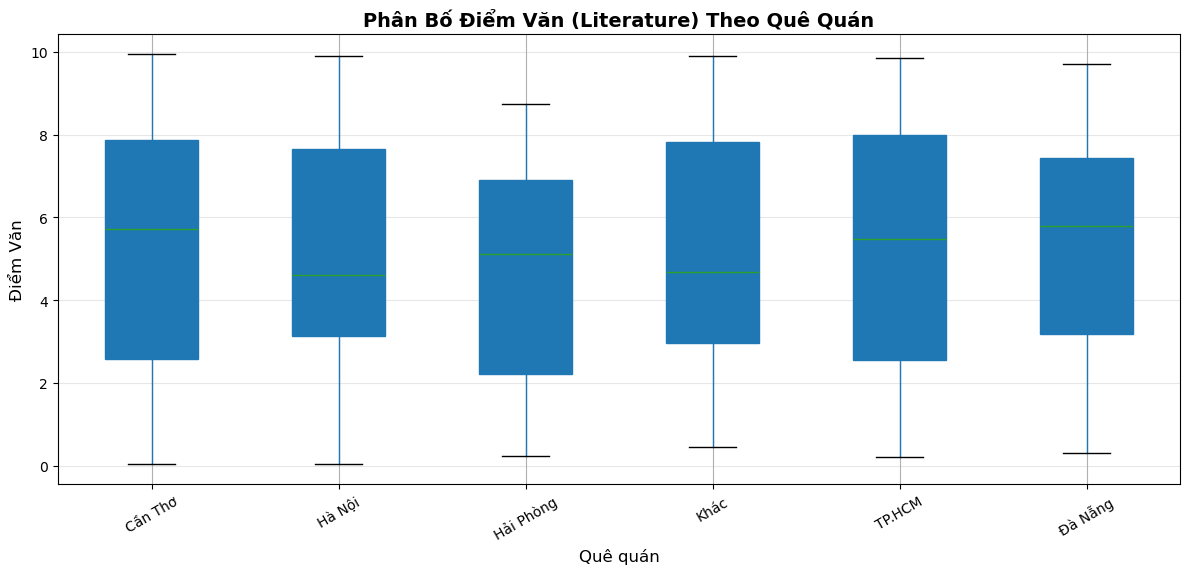

In [430]:
plt.figure(figsize=(12, 6))
df.boxplot(column='Literature', by='Hometown',
           patch_artist=True, grid=True, ax=plt.gca())
plt.suptitle('')
plt.title('Phân Bố Điểm Văn (Literature) Theo Quê Quán', fontsize=14, fontweight='bold')
plt.xlabel('Quê quán', fontsize=12)
plt.ylabel('Điểm Văn', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


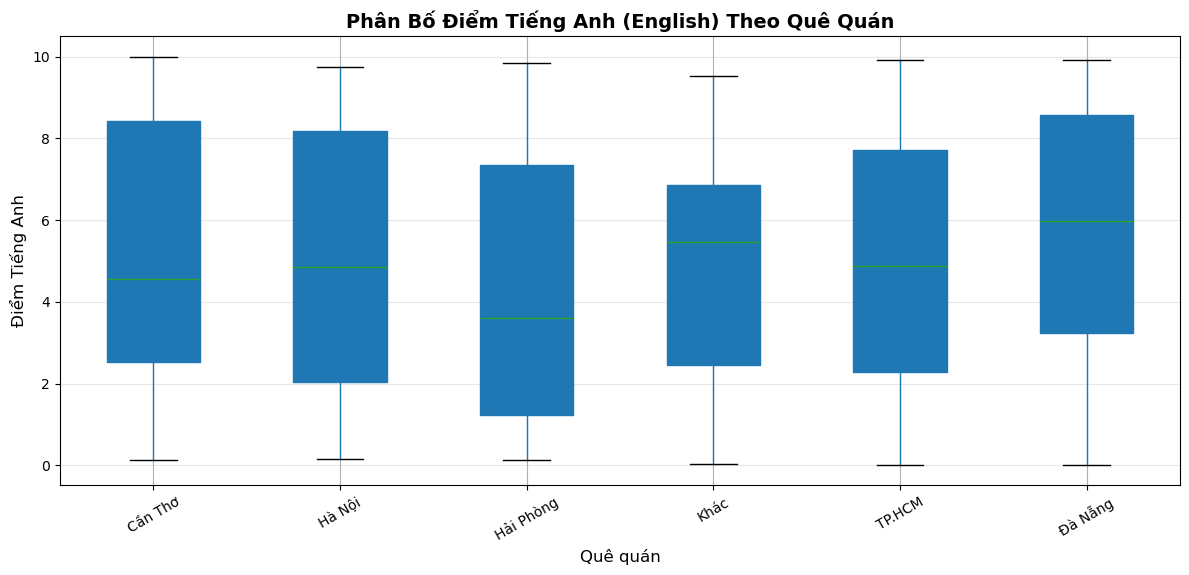

In [431]:
plt.figure(figsize=(12, 6))
df.boxplot(column='Eng', by='Hometown',
           patch_artist=True, grid=True, ax=plt.gca())
plt.suptitle('')
plt.title('Phân Bố Điểm Tiếng Anh (English) Theo Quê Quán', fontsize=14, fontweight='bold')
plt.xlabel('Quê quán', fontsize=12)
plt.ylabel('Điểm Tiếng Anh', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


### Nhận xét sự khác biệt

In [432]:
print("\n" + "=" * 70)
print("NHẬN XÉT VÀ XU HƯỚNG THEO QUÊ QUÁN")
print("=" * 70)

# Nhóm thành phố lớn vs khu vực khác
big_cities = df[df['Hometown'].isin(['Hà Nội', 'TP.HCM'])]
others = df[df['Hometown'] == 'Khác']

print("\n1. So sánh Thành phố lớn (Hà Nội, TP.HCM) vs Khu vực khác:")

for subject, name in [('Math', 'Toán'), ('Literature', 'Văn'), ('Eng', 'Tiếng Anh')]:
    big_mean = big_cities[subject].mean()
    other_mean = others[subject].mean()
    diff = big_mean - other_mean

    print(f"\n   Môn {name}:")
    print(f"   - Thành phố lớn: {big_mean:.2f}")
    print(f"   - Khu vực khác : {other_mean:.2f}")

    if diff > 0:
        print(f"   → Sinh viên thành phố lớn cao hơn {diff:.2f} điểm")
    elif diff < 0:
        print(f"   → Sinh viên khu vực khác cao hơn {abs(diff):.2f} điểm")
    else:
        print("   → Không có sự chênh lệch đáng kể")

print("\n2. Phân tích riêng môn Tiếng Anh theo quê quán:")

for hometown in df['Hometown'].unique():
    mean_eng = df[df['Hometown'] == hometown]['Eng'].mean()
    print(f"   - {hometown}: {mean_eng:.2f}")

best_hometown_eng = df.groupby('Hometown')['Eng'].mean().idxmax()
best_score_eng = df.groupby('Hometown')['Eng'].mean().max()

print(f"\n   → Quê quán có điểm Tiếng Anh trung bình cao nhất: {best_hometown_eng} ({best_score_eng:.2f})")

print("\n3. Nhận định xu hướng tổng quát:")
print("   - Có sự khác biệt điểm số theo yếu tố địa lý")
print("   - Thành phố lớn thường có lợi thế về ngoại ngữ và điều kiện học tập")
print("   - Một số khu vực khác có thể nổi trội ở môn tự nhiên hoặc xã hội")
print("   - Cần phân tích thêm theo: điều kiện kinh tế, chất lượng giáo dục địa phương, môi trường học tập")



NHẬN XÉT VÀ XU HƯỚNG THEO QUÊ QUÁN

1. So sánh Thành phố lớn (Hà Nội, TP.HCM) vs Khu vực khác:

   Môn Toán:
   - Thành phố lớn: 4.59
   - Khu vực khác : 4.67
   → Sinh viên khu vực khác cao hơn 0.07 điểm

   Môn Văn:
   - Thành phố lớn: 5.22
   - Khu vực khác : 5.21
   → Sinh viên thành phố lớn cao hơn 0.02 điểm

   Môn Tiếng Anh:
   - Thành phố lớn: 4.97
   - Khu vực khác : 4.87
   → Sinh viên thành phố lớn cao hơn 0.10 điểm

2. Phân tích riêng môn Tiếng Anh theo quê quán:
   - Hà Nội: 4.96
   - Hải Phòng: 4.35
   - Cần Thơ: 5.21
   - TP.HCM: 4.99
   - Khác: 4.87
   - Đà Nẵng: 5.72

   → Quê quán có điểm Tiếng Anh trung bình cao nhất: Đà Nẵng (5.72)

3. Nhận định xu hướng tổng quát:
   - Có sự khác biệt điểm số theo yếu tố địa lý
   - Thành phố lớn thường có lợi thế về ngoại ngữ và điều kiện học tập
   - Một số khu vực khác có thể nổi trội ở môn tự nhiên hoặc xã hội
   - Cần phân tích thêm theo: điều kiện kinh tế, chất lượng giáo dục địa phương, môi trường học tập


# VI Phân tích theo độ tuổi

In [433]:
# Nhóm tuổi
def group_age(age):
    if pd.isna(age):
        return 'Không xác định'
    elif age <= 20:
        return '≤ 20'
    elif age <= 22:
        return '21-22'
    else:
        return '≥ 23'

df['AgeGroup'] = df['Age'].apply(group_age)

print("=" * 70)
print("PHÂN TÍCH THEO ĐỘ TUỔI")
print("=" * 70)

print("\nPhân bố nhóm tuổi:")
age_group_counts = df['AgeGroup'].value_counts()
for group in ['≤ 20', '21-22', '≥ 23']:
    if group in age_group_counts.index:
        count = age_group_counts[group]
        pct = (count / len(df)) * 100
        print(f"  {group:15} : {count:3} sinh viên ({pct:5.2f}%)")

print("\nĐiểm trung bình theo nhóm tuổi:")
age_group_avg = df[df['AgeGroup'] != 'Không xác định'].groupby('AgeGroup')[['Math', 'Literature', 'Eng', 'Avg']].mean()
print(age_group_avg.round(2))

PHÂN TÍCH THEO ĐỘ TUỔI

Phân bố nhóm tuổi:
  ≤ 20            : 149 sinh viên (37.25%)
  21-22           : 119 sinh viên (29.75%)
  ≥ 23            :  48 sinh viên (12.00%)

Điểm trung bình theo nhóm tuổi:
          Math  Literature   Eng   Avg
AgeGroup                              
21-22     5.30        4.95  5.25  5.06
≤ 20      4.79        5.22  4.93  4.95
≥ 23      4.72        4.77  5.18  5.09


số lượng sinh viên theo nhóm tuổi

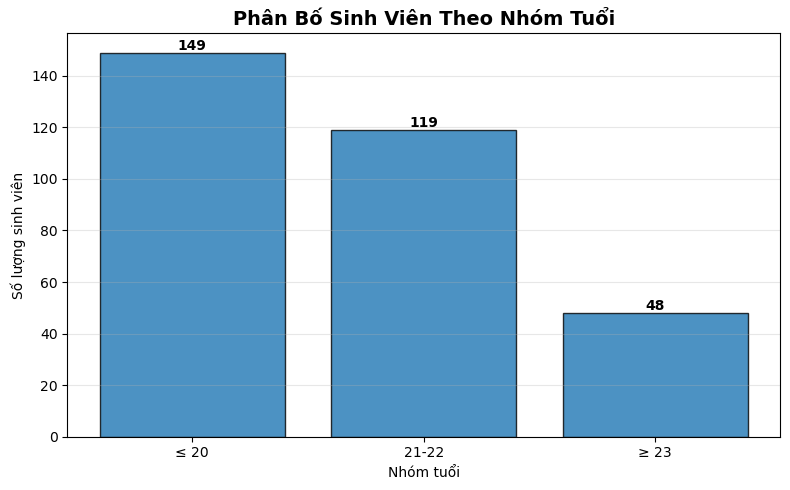

In [434]:
plt.figure(figsize=(8, 5))
age_group_counts = df['AgeGroup'].value_counts().reindex(['≤ 20', '21-22', '≥ 23'])

bars = plt.bar(age_group_counts.index, age_group_counts.values, alpha=0.8, edgecolor='black')
plt.title('Phân Bố Sinh Viên Theo Nhóm Tuổi', fontsize=14, fontweight='bold')
plt.xlabel('Nhóm tuổi')
plt.ylabel('Số lượng sinh viên')
plt.grid(axis='y', alpha=0.3)

# Hiển thị số trên cột
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h, f'{int(h)}', 
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


Phân bố điểm theo nhóm tuổi

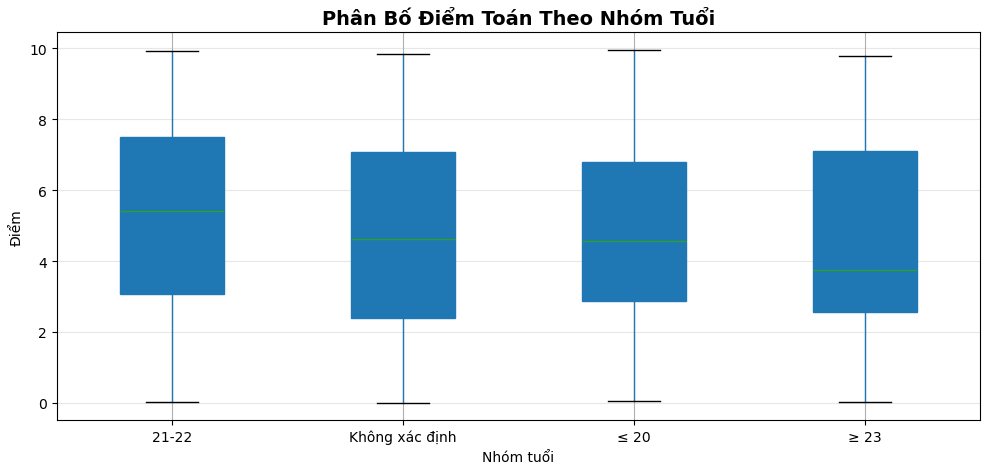

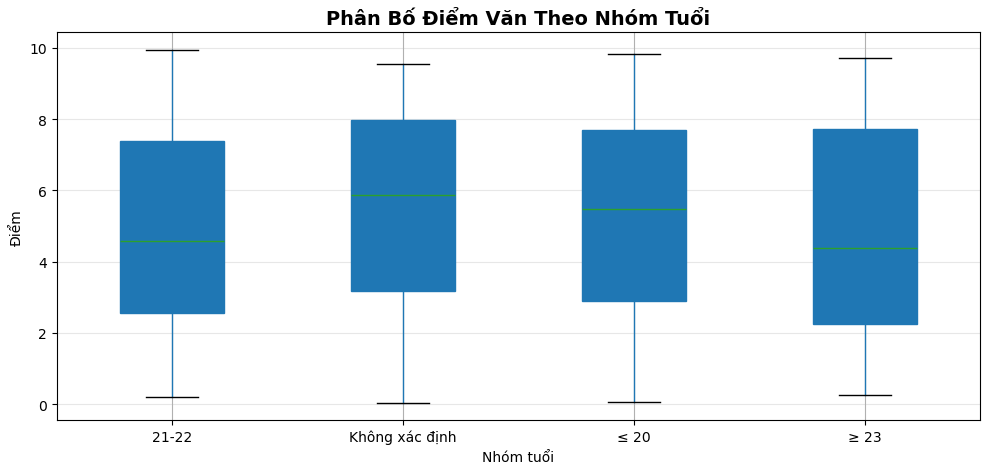

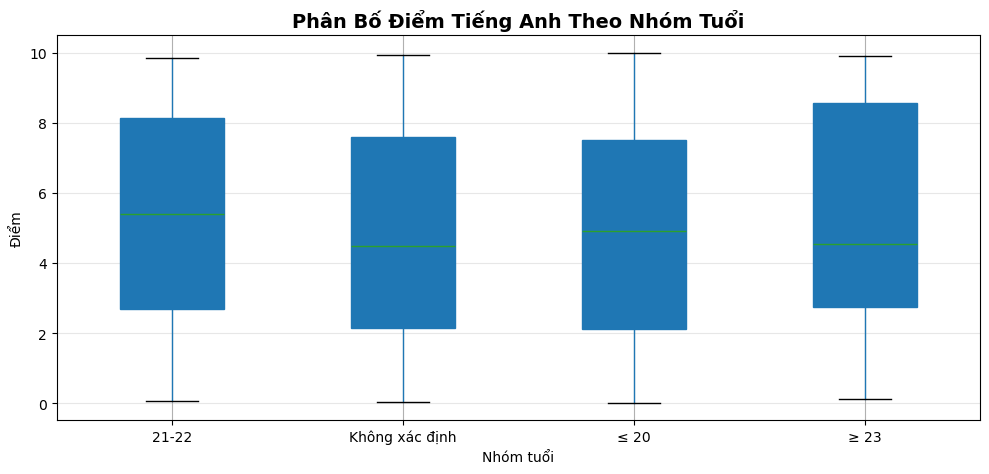

In [435]:
subjects = ['Math', 'Literature', 'Eng']
titles = ['Toán', 'Văn', 'Tiếng Anh']

for subject, title in zip(subjects, titles):
    plt.figure(figsize=(10, 5))
    df.boxplot(column=subject, by='AgeGroup',
               patch_artist=True, grid=True, ax=plt.gca())
    plt.suptitle('')
    plt.title(f'Phân Bố Điểm {title} Theo Nhóm Tuổi', fontsize=14, fontweight='bold')
    plt.xlabel('Nhóm tuổi')
    plt.ylabel('Điểm')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


<Figure size 1000x500 with 0 Axes>

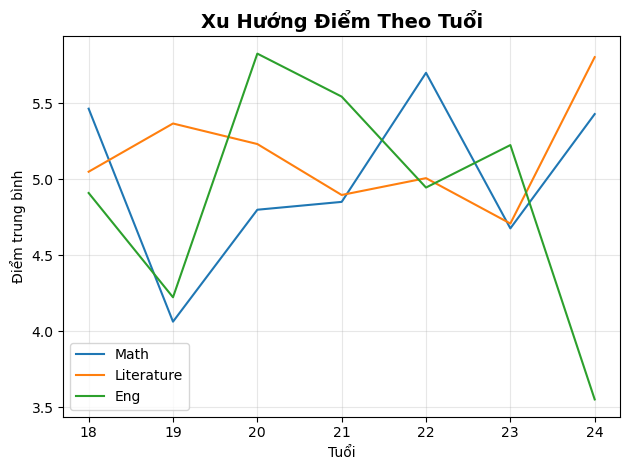

In [436]:
plt.figure(figsize=(10, 5))
df.groupby('Age')[['Math','Literature','Eng']].mean().plot()
plt.title('Xu Hướng Điểm Theo Tuổi', fontsize=14, fontweight='bold')
plt.xlabel('Tuổi')
plt.ylabel('Điểm trung bình')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


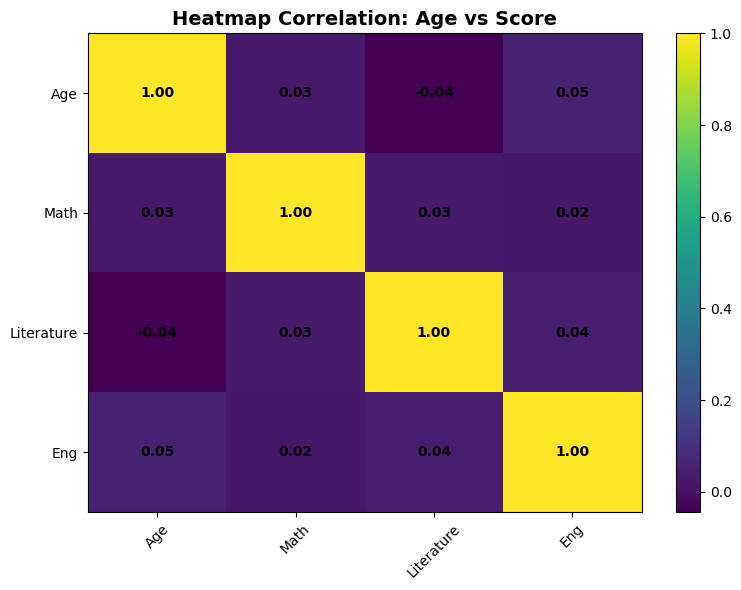

In [437]:
# Correlation Age vs Scores
corr_df = df[['Age', 'Math', 'Literature', 'Eng']].corr()

plt.figure(figsize=(8, 6))
im = plt.imshow(corr_df, aspect='auto')
plt.colorbar(im)

plt.xticks(range(len(corr_df.columns)), corr_df.columns, rotation=45)
plt.yticks(range(len(corr_df.index)), corr_df.index)

# Ghi giá trị correlation lên từng ô
for i in range(len(corr_df.index)):
    for j in range(len(corr_df.columns)):
        value = corr_df.iloc[i, j]
        plt.text(j, i, f"{value:.2f}", ha="center", va="center", fontweight="bold")

plt.title('Heatmap Correlation: Age vs Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# VII - Phân tích phục vụ quản lý sinh viên

In [438]:
print("=" * 70)
print("PHÂN TÍCH PHỤC VỤ QUẢN LÝ SINH VIÊN")
print("=" * 70)

# Top 10 sinh viên có Avg cao nhất
print("\nTOP 10 SINH VIÊN CÓ ĐIỂM TRUNG BÌNH CAO NHẤT:")
top_10_students = df.nlargest(10, 'Avg')[['ID', 'Fullname', 'Hometown', 'Math', 'Literature', 'Eng', 'Avg']]
print(top_10_students.to_string(index=False))

# Top sinh viên giỏi Tiếng Anh
print("\nTOP 10 SINH VIÊN GIỎI TIẾNG ANH:")
top_eng_students = df.nlargest(10, 'Eng')[['ID', 'Fullname', 'Hometown', 'Eng', 'Avg']]
print(top_eng_students.to_string(index=False))

PHÂN TÍCH PHỤC VỤ QUẢN LÝ SINH VIÊN

TOP 10 SINH VIÊN CÓ ĐIỂM TRUNG BÌNH CAO NHẤT:
    ID          Fullname  Hometown  Math  Literature   Eng  Avg
SV1132  Thành Văn Nguyễn   Cần Thơ   NaN        9.78 10.00 9.89
SV1267  Hoàng Quang Phạm    TP.HCM   NaN         NaN  9.84 9.84
SV1232        Xuân Hoàng    Hà Nội  9.78         NaN   NaN 9.78
SV1104    Bảo Quang Đặng Hải Phòng   NaN         NaN  9.57 9.57
SV1088          Chi Đặng      Khác  9.91        9.20   NaN 9.56
SV1193       Nhiên Hoàng    TP.HCM   NaN        9.51   NaN 9.51
SV1012        Hải Tấn Vũ    TP.HCM   NaN        9.43   NaN 9.43
SV1209      Thành Nguyễn   Cần Thơ  9.35        8.90   NaN 9.12
SV1286 Châu Quang Nguyễn    TP.HCM   NaN        9.84  8.31 9.07
SV1026           Tú Trần    Hà Nội  8.86        9.43  8.80 9.03

TOP 10 SINH VIÊN GIỎI TIẾNG ANH:
    ID         Fullname  Hometown   Eng  Avg
SV1132 Thành Văn Nguyễn   Cần Thơ 10.00 9.89
SV1043           An Mai   Đà Nẵng  9.93 6.89
SV1214        Hạnh Trần    TP.HCM  9.91 8.17

In [439]:
print("\nDANH SÁCH SINH VIÊN XUẤT SẮC TOÀN DIỆN (>= 8 cả 3 môn):")

excellent_students = df[
    (df['Math'] >= 8) &
    (df['Literature'] >= 8) &
    (df['Eng'] >= 8)
][['ID','Fullname','Hometown','Math','Literature','Eng','Avg']]

if len(excellent_students) > 0:
    print(excellent_students.sort_values('Avg', ascending=False).to_string(index=False))
    print(f"\nTổng số: {len(excellent_students)} sinh viên")
else:
    print("Không có sinh viên đạt xuất sắc toàn diện")



DANH SÁCH SINH VIÊN XUẤT SẮC TOÀN DIỆN (>= 8 cả 3 môn):
    ID Fullname Hometown  Math  Literature  Eng  Avg
SV1026  Tú Trần   Hà Nội  8.86        9.43  8.8 9.03

Tổng số: 1 sinh viên


In [440]:
print("\nSINH VIÊN LỆCH MÔN (1 môn >= 8, 1 môn < 5):")

imbalanced_students = df[
    (
        ((df['Math'] >= 8) & ((df['Literature'] < 5) | (df['Eng'] < 5))) |
        ((df['Literature'] >= 8) & ((df['Math'] < 5) | (df['Eng'] < 5))) |
        ((df['Eng'] >= 8) & ((df['Math'] < 5) | (df['Literature'] < 5)))
    )
][['ID','Fullname','Hometown','Math','Literature','Eng','Avg']]

if len(imbalanced_students) > 0:
    print(imbalanced_students.sort_values('Avg', ascending=False).to_string(index=False))
    print(f"\nTổng số: {len(imbalanced_students)} sinh viên")
else:
    print("Không có sinh viên lệch môn rõ rệt")



SINH VIÊN LỆCH MÔN (1 môn >= 8, 1 môn < 5):
    ID         Fullname  Hometown  Math  Literature  Eng  Avg
SV1320        Bảo Dương    TP.HCM  8.76        9.43 3.95 7.38
SV1393        Vân Dương   Đà Nẵng  9.76        3.26 8.92 7.31
SV1280               Vũ   Đà Nẵng  8.94        3.89 8.95 7.26
SV1397           Tú Bùi    Hà Nội  4.25        8.37 9.08 7.23
SV1264     Hương Nguyễn    Hà Nội  8.72        4.61 8.13 7.15
SV1291   Nam Quang Trần      Khác  4.40        8.57 8.34 7.10
SV1343          Tùng Lê   Đà Nẵng  7.78        8.58 4.93 7.10
SV1194         Kim Đặng   Cần Thơ  9.51        9.67 1.84 7.01
SV1043           An Mai   Đà Nẵng  7.98        2.76 9.93 6.89
SV1230           Hải Lê Hải Phòng  2.31        8.37 9.85 6.84
SV1150        Vi Nguyễn    TP.HCM  9.24        4.33  NaN 6.78
SV1084          Kim Bùi    Hà Nội   NaN        8.56 4.91 6.74
SV1063        Chi Hoàng    TP.HCM  8.94        7.66 3.55 6.72
SV1117        Khoa Đặng    TP.HCM  9.88         NaN 3.40 6.64
SV1391         Vân Phạm  

### Danh sách cảnh báo

In [441]:
# Sinh viên có Avg < 5
print("\nDANH SÁCH SINH VIÊN CẦN HỖ TRỢ (Avg < 5):")
weak_students = df[df['Avg'] < 5][['ID', 'Fullname', 'Hometown', 'Math', 'Literature', 'Eng', 'Avg']].sort_values('Avg')
if len(weak_students) > 0:
    print(weak_students.to_string(index=False))
    print(f"\nTổng số: {len(weak_students)} sinh viên")
else:
    print("Không có sinh viên nào có điểm trung bình < 5")

# Sinh viên có từ 2 môn trở lên dưới 5
print("\nDANH SÁCH SINH VIÊN CÓ TỪ 2 MÔN TRỞ LÊN DƯỚI 5 (Nguy cơ cao):")
df['FailedSubjects'] = ((df['Math'] < 5).astype(int) + 
                        (df['Literature'] < 5).astype(int) + 
                        (df['Eng'] < 5).astype(int))
high_risk_students = df[df['FailedSubjects'] >= 2][['ID', 'Fullname', 'Hometown', 'Math', 'Literature', 'Eng', 'Avg', 'FailedSubjects']].sort_values('FailedSubjects', ascending=False)
if len(high_risk_students) > 0:
    print(high_risk_students.to_string(index=False))
    print(f"\nTổng số: {len(high_risk_students)} sinh viên")
else:
    print("Không có sinh viên nào có từ 2 môn trở lên dưới 5")


DANH SÁCH SINH VIÊN CẦN HỖ TRỢ (Avg < 5):
    ID          Fullname  Hometown  Math  Literature  Eng  Avg
SV1086         Hữu Dương    TP.HCM   NaN         NaN 0.15 0.15
SV1115       Phương Phạm    Hà Nội   NaN         NaN 0.16 0.16
SV1126    Hải Hoàng Trần    TP.HCM   NaN        0.29  NaN 0.29
SV1054        Mai Nguyễn   Cần Thơ   NaN         NaN 0.34 0.34
SV1208     Lâm Phú Hoàng Hải Phòng  0.02         NaN 0.80 0.41
SV1344          Dương Lê Hải Phòng  0.29         NaN 0.62 0.45
SV1044       Hải Bảo Mai   Cần Thơ   NaN        0.51  NaN 0.51
SV1238       Thành Hoàng    TP.HCM   NaN        0.57  NaN 0.57
SV1290           Châu Lê    Hà Nội  0.95         NaN 0.35 0.65
SV1341      Nam Đức Trần    TP.HCM  1.17         NaN 0.16 0.66
SV1379       Khoa Nguyễn      Khác   NaN        1.74 0.07 0.90
SV1285        Hương Trần      Khác  1.58         NaN 0.41 1.00
SV1051            Hà Bùi    TP.HCM  1.07         NaN  NaN 1.07
SV1364        Lâm Nguyễn Hải Phòng   NaN        1.07  NaN 1.07
SV1346      

In [442]:
def risk_level(row):
    fail = ((row['Math'] < 5) + (row['Literature'] < 5) + (row['Eng'] < 5))
    if fail >= 2:
        return 'Nguy cơ cao'
    elif fail == 1:
        return 'Nguy cơ'
    elif row['Avg'] < 5:
        return 'Cảnh báo'
    else:
        return 'Bình thường'

df['RiskLevel'] = df.apply(risk_level, axis=1)

print("\nPHÂN LOẠI RỦI RO HỌC TẬP:")
print(df['RiskLevel'].value_counts().to_string())



PHÂN LOẠI RỦI RO HỌC TẬP:
RiskLevel
Nguy cơ        169
Nguy cơ cao    134
Bình thường     97
